In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/datassd/proyectos/terravision/terravision_sensor_data/canteras/canteras_atmos.nc"
# ----------------------------
# 1) Load + basic cleaning
# ----------------------------
ds = xr.open_dataset(PATH, engine="netcdf4")

# Ensure time is usable
time = pd.to_datetime(ds["time"].values)
valid = ~time.isna()

ds = ds.isel(time=valid)
ds = ds.sortby("time")

# Drop duplicate timestamps (keep first)
t = pd.to_datetime(ds["time"].values)
dup_mask = t.duplicated(keep="first")
if dup_mask.any():
    ds = ds.isel(time=~xr.DataArray(dup_mask, dims="time"))

# ----------------------------
# 2) Dataset summary
# ----------------------------
summary = {
    "n_vars": len(ds.data_vars),
    "n_time": ds.sizes.get("time", None),
    "time_start": str(pd.to_datetime(ds.time.values[0])),
    "time_end": str(pd.to_datetime(ds.time.values[-1])),
}
summary



{'n_vars': 18,
 'n_time': 25693,
 'time_start': '2025-06-01 00:00:00',
 'time_end': '2025-11-30 23:50:00'}

In [4]:
# ----------------------------
# 3) Cadence + gaps
# ----------------------------
t = pd.to_datetime(ds.time.values)
dt = t.to_series().diff().dropna()

cadence_seconds = dt.dt.total_seconds()
cadence_desc = cadence_seconds.describe(percentiles=[0.5, 0.9, 0.99]).to_frame("seconds")
cadence_desc["timedelta"] = pd.to_timedelta(cadence_desc["seconds"], unit="s").astype(str)

# Gaps above a threshold (e.g., > 30 minutes)
gap_threshold = pd.Timedelta(minutes=30)
gaps = dt[dt > gap_threshold].sort_values(ascending=False)

gaps_df = pd.DataFrame({
    "gap": gaps.values.astype("timedelta64[ns]"),
    "gap_str": gaps.astype(str).values,
    "time_after_gap": gaps.index.astype("datetime64[ns]"),
    "time_before_gap": (gaps.index - gaps.values).astype("datetime64[ns]"),
}).head(20)

print("Cadence (seconds) summary", cadence_desc.reset_index().rename(columns={"index": "stat"}))
print("Largest gaps (>30 min) — top 20", gaps_df)
cadence_desc.head(), len(gaps)



Cadence (seconds) summary     stat        seconds                  timedelta
0  count   25692.000000            0 days 07:08:12
1   mean     615.390005  0 days 00:10:15.390004671
2    std    1059.098251  0 days 00:17:39.098250791
3    min     600.000000            0 days 00:10:00
4    50%     600.000000            0 days 00:10:00
5    90%     600.000000            0 days 00:10:00
6    99%     600.000000            0 days 00:10:00
7    max  166200.000000            1 days 22:10:00
Largest gaps (>30 min) — top 20               gap          gap_str      time_after_gap     time_before_gap
0 1 days 22:10:00  1 days 22:10:00 2025-08-25 07:10:00 2025-08-23 09:00:00
1 0 days 06:30:00  0 days 06:30:00 2025-06-27 09:50:00 2025-06-27 03:20:00
2 0 days 06:10:00  0 days 06:10:00 2025-06-24 09:20:00 2025-06-24 03:10:00
3 0 days 03:20:00  0 days 03:20:00 2025-07-31 15:00:00 2025-07-31 11:40:00
4 0 days 02:20:00  0 days 02:20:00 2025-07-14 14:00:00 2025-07-14 11:40:00
5 0 days 02:10:00  0 days 02:10:0

(            seconds                  timedelta
 count  25692.000000            0 days 07:08:12
 mean     615.390005  0 days 00:10:15.390004671
 std     1059.098251  0 days 00:17:39.098250791
 min      600.000000            0 days 00:10:00
 50%      600.000000            0 days 00:10:00,
 10)

In [5]:
# ----------------------------
# 4) Missingness + basic stats per variable
# ----------------------------
var_rows = []
missing_rows = []

for v in ds.data_vars:
    da = ds[v]
    # only handle numeric 1D time vars here
    if "time" not in da.dims or da.ndim != 1:
        continue
    
    arr = da.values.astype("float64")
    n = arr.size
    n_missing = np.isnan(arr).sum()
    missing_rows.append({
        "variable": v,
        "missing_count": int(n_missing),
        "missing_pct": float(n_missing / n * 100),
    })
    
    s = pd.Series(arr)
    var_rows.append({
        "variable": v,
        "dtype": str(da.dtype),
        "min": float(np.nanmin(arr)) if n_missing < n else np.nan,
        "p01": float(s.quantile(0.01, interpolation="linear")) if n_missing < n else np.nan,
        "p05": float(s.quantile(0.05, interpolation="linear")) if n_missing < n else np.nan,
        "median": float(np.nanmedian(arr)) if n_missing < n else np.nan,
        "mean": float(np.nanmean(arr)) if n_missing < n else np.nan,
        "std": float(np.nanstd(arr)) if n_missing < n else np.nan,
        "p95": float(s.quantile(0.95, interpolation="linear")) if n_missing < n else np.nan,
        "p99": float(s.quantile(0.99, interpolation="linear")) if n_missing < n else np.nan,
        "max": float(np.nanmax(arr)) if n_missing < n else np.nan,
    })

missing_df = pd.DataFrame(missing_rows).sort_values(["missing_pct", "variable"], ascending=[False, True])
stats_df = pd.DataFrame(var_rows).sort_values("variable")

print("Missingness per variable", missing_df)
print("Basic stats per variable", stats_df)
missing_df.head(), stats_df.head()



Missingness per variable                       variable  missing_count  missing_pct
14          evapotranspiracion          25693   100.000000
5     indice_de_calor_interior          25693   100.000000
3      punto_de_rocio_interior          25693   100.000000
12         presion_atmosferica          23055    89.732612
16             radiacion_solar              2     0.007784
11  direccion_media_del_viento              0     0.000000
8                      humedad              0     0.000000
7             humedad_interior              0     0.000000
6              indice_de_calor              0     0.000000
17                   indice_uv              0     0.000000
15        intensidad_de_lluvia              0     0.000000
13                      lluvia              0     0.000000
4               punto_de_rocio              0     0.000000
9      rafaga_maxima_de_viento              0     0.000000
2            sensacion_termica              0     0.000000
1                  temperatura 

(                    variable  missing_count  missing_pct
 14        evapotranspiracion          25693   100.000000
 5   indice_de_calor_interior          25693   100.000000
 3    punto_de_rocio_interior          25693   100.000000
 12       presion_atmosferica          23055    89.732612
 16           radiacion_solar              2     0.007784,
                       variable    dtype   min   p01   p05  median        mean  \
 11  direccion_media_del_viento  float64   0.0  24.0  55.0   222.0  195.341260   
 14          evapotranspiracion  float64   NaN   NaN   NaN     NaN         NaN   
 8                      humedad  float64  12.0  20.0  24.0    49.0   52.180283   
 7             humedad_interior  float64  19.0  22.0  26.0    39.0   40.320905   
 6              indice_de_calor  float64   1.9   4.8   8.6    22.3   21.533776   
 
           std    p95    p99    max  
 11  75.308041  283.0  308.0  359.0  
 14        NaN    NaN    NaN    NaN  
 8   20.625753   89.0   95.0   98.0  
 7   

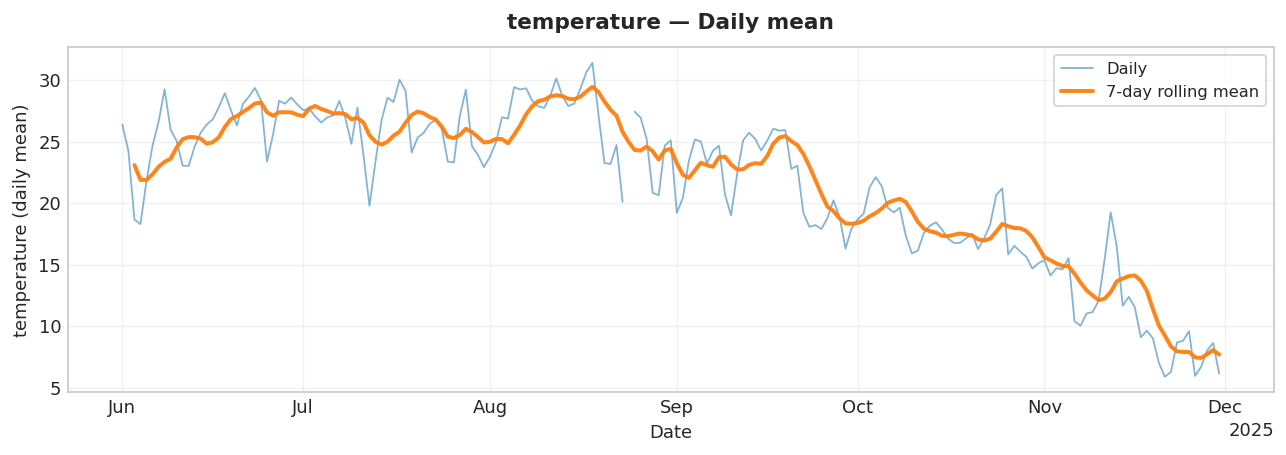

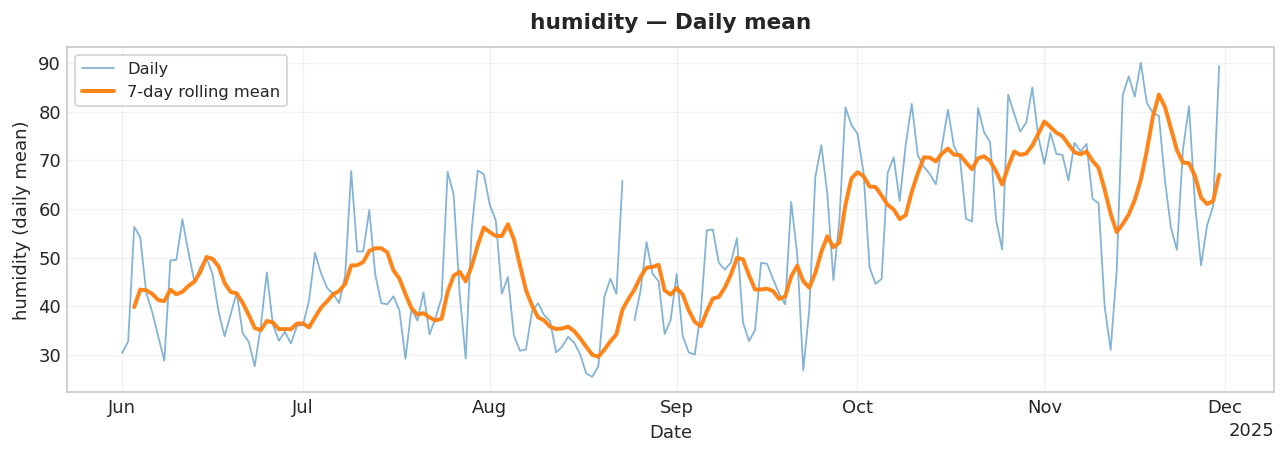

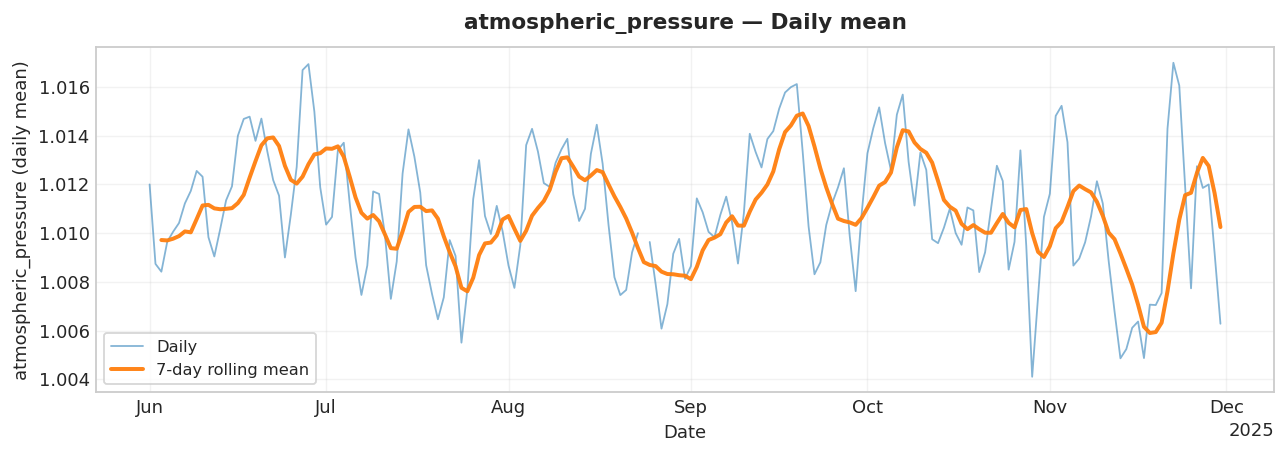

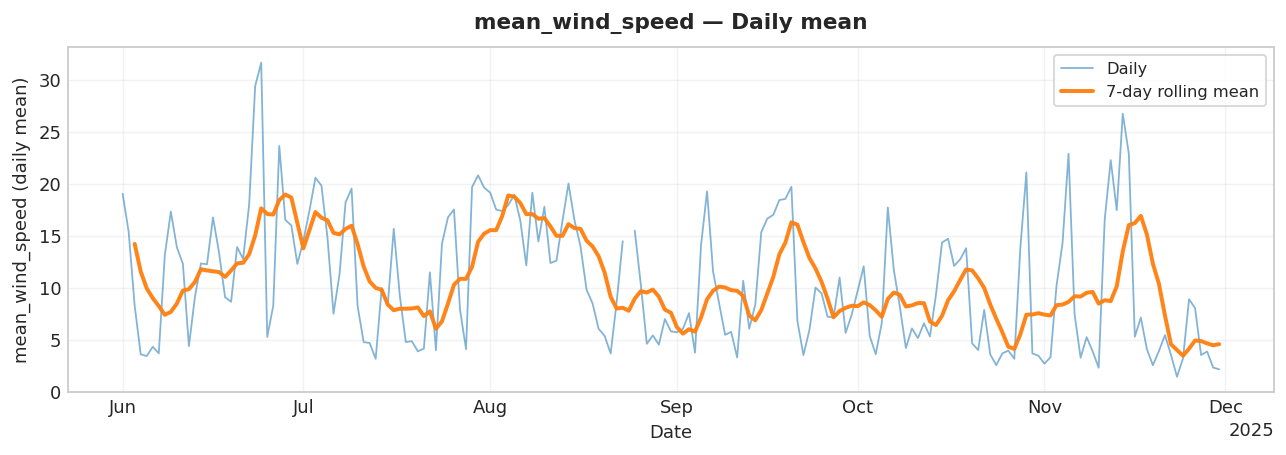

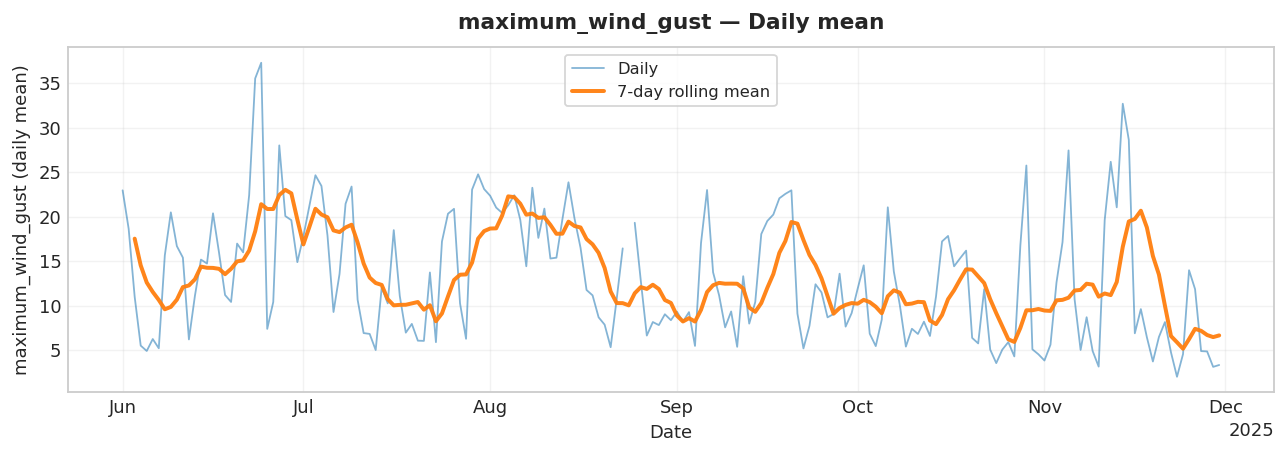

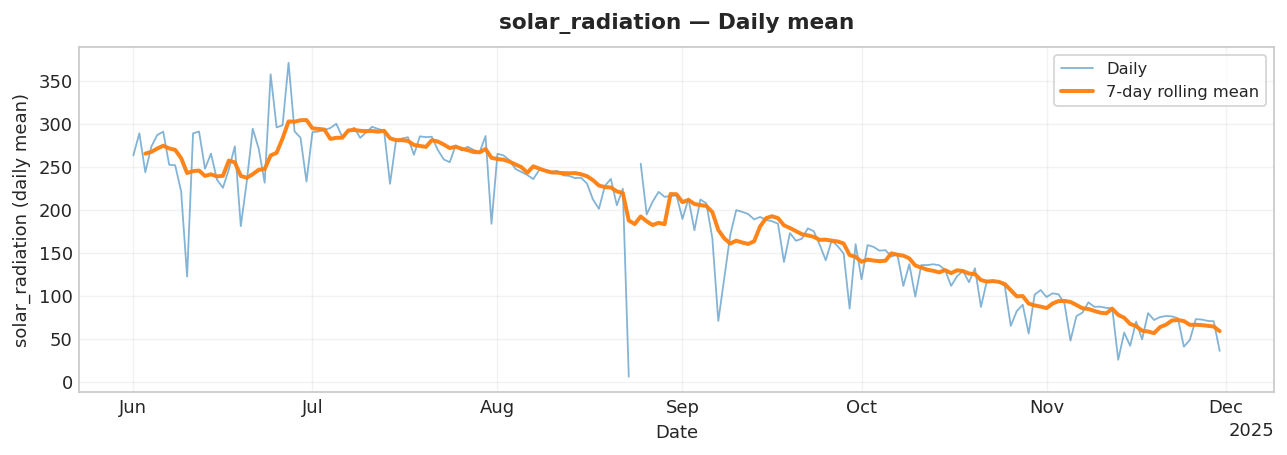

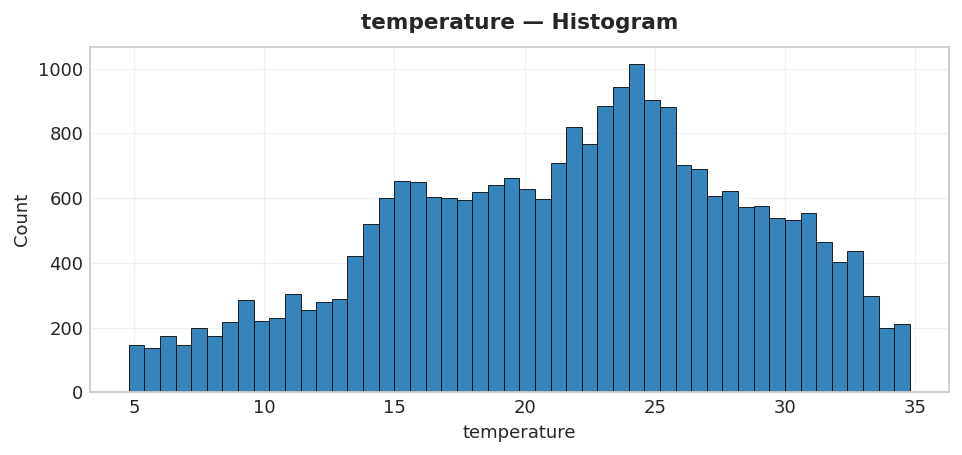

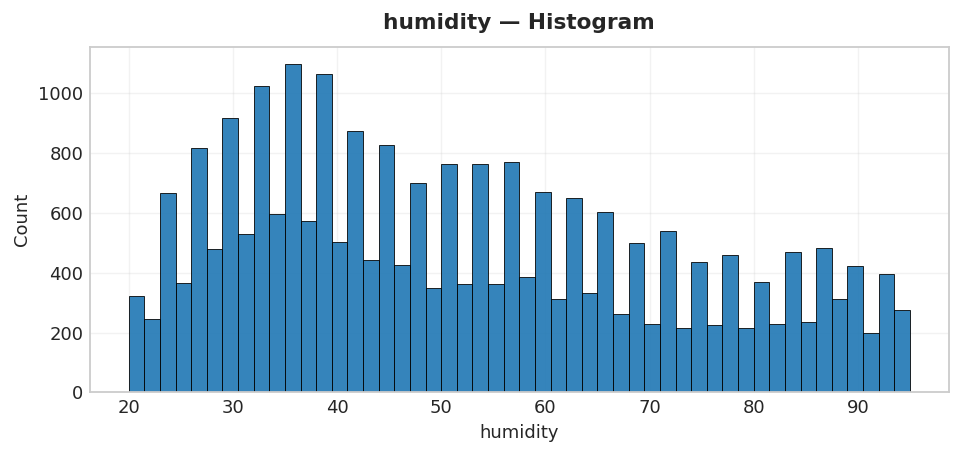

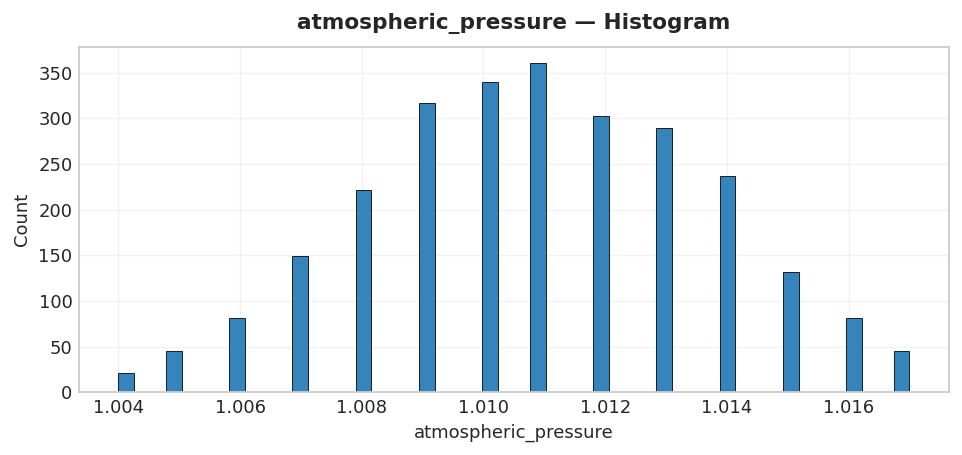

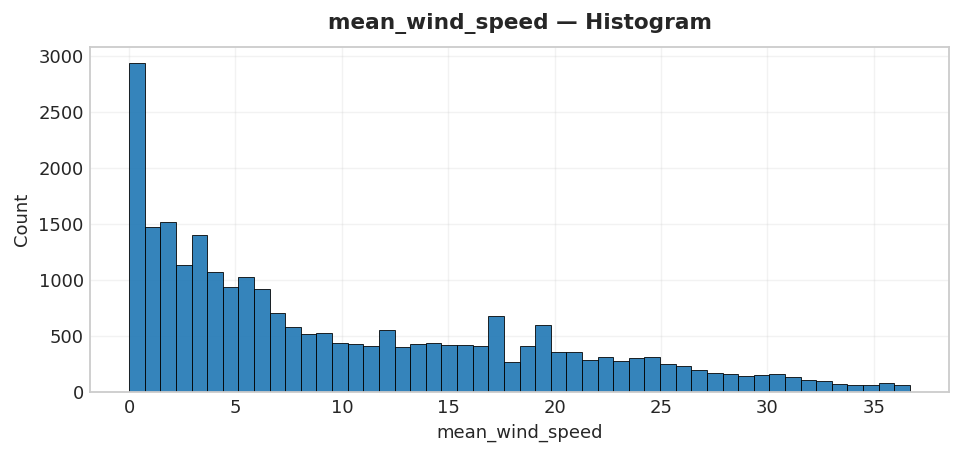

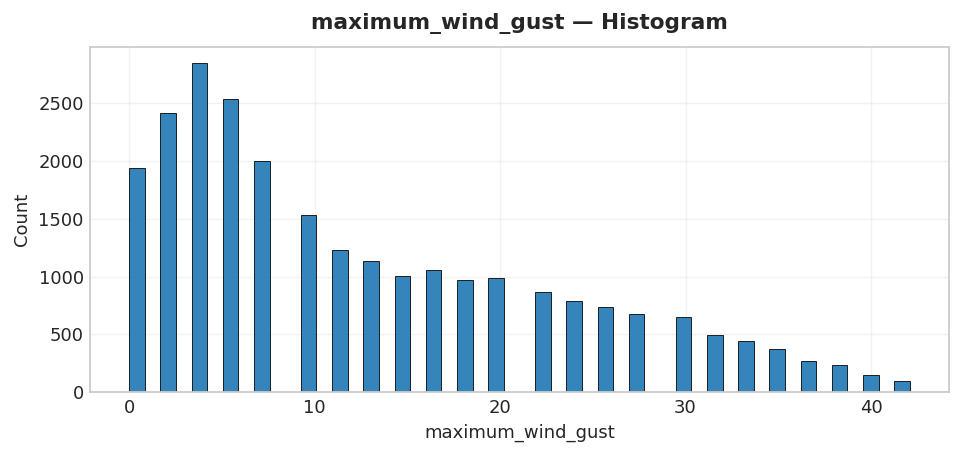

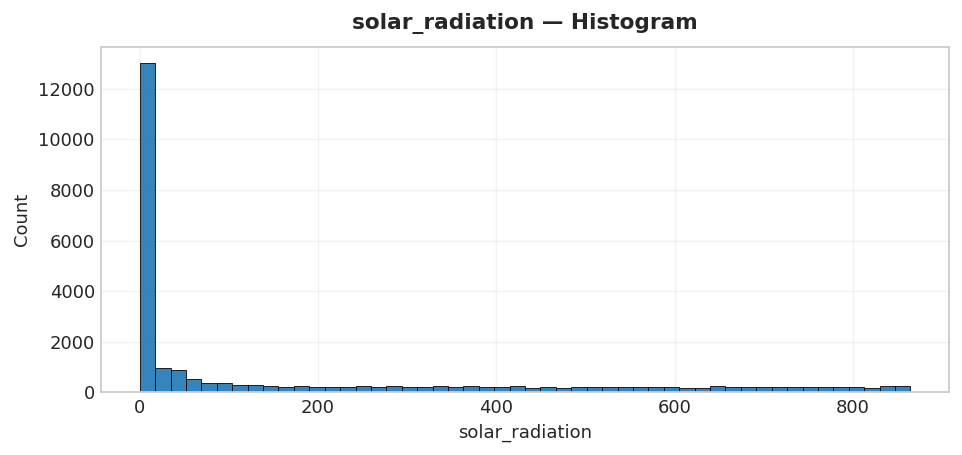

(['temperatura',
  'humedad',
  'presion_atmosferica',
  'velocidad_media_del_viento',
  'rafaga_maxima_de_viento',
  'radiacion_solar'],
 (25693, 6))

In [8]:
# ----------------------------
# 5) Quick visuals (prettier + English)
# ----------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Use a clean style (built-in)
plt.style.use("seaborn-v0_8-whitegrid")

# If you already created this earlier, keep it; otherwise define it:
es_to_en = {
    "temperatura_interior": "indoor_temperature",
    "temperatura": "temperature",
    "sensacion_termica": "thermal_sensation",
    "punto_de_rocio_interior": "indoor_dew_point",
    "punto_de_rocio": "dew_point",
    "indice_de_calor_interior": "indoor_heat_index",
    "indice_de_calor": "heat_index",
    "humedad_interior": "indoor_humidity",
    "humedad": "humidity",
    "rafaga_maxima_de_viento": "maximum_wind_gust",
    "velocidad_media_del_viento": "mean_wind_speed",
    "direccion_media_del_viento": "mean_wind_direction",
    "presion_atmosferica": "atmospheric_pressure",
    "lluvia": "rainfall",
    "evapotranspiracion": "evapotranspiration",
    "intensidad_de_lluvia": "rainfall_intensity",
    "radiacion_solar": "solar_radiation",
    "indice_uv": "uv_index",
}

# Variables with at least some non-missing data
good_vars = missing_df.loc[missing_df["missing_pct"] < 100, "variable"].tolist()

# Choose a handful of representative variables (up to 6)
preferred_order = [
    "temperatura", "humedad", "presion_atmosferica",
    "velocidad_media_del_viento", "rafaga_maxima_de_viento",
    "radiacion_solar", "lluvia", "intensidad_de_lluvia",
    "indice_uv", "sensacion_termica", "punto_de_rocio"
]
plot_vars = [v for v in preferred_order if v in good_vars][:6]
if not plot_vars:
    plot_vars = good_vars[:6]

# Create a DataFrame for easy resampling
df = ds[plot_vars].to_dataframe()

def pretty_name(var: str) -> str:
    return es_to_en.get(var, var)

def format_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.10)

# ----------------------------
# Time series: daily aggregate + 7-day rolling
# ----------------------------
for v in plot_vars:
    series = df[v].dropna()
    if series.empty:
        continue

    is_rain = v in {"lluvia", "intensidad_de_lluvia"}

    if is_rain:
        daily = series.resample("1D").sum(min_count=1)
        ylabel = f"{pretty_name(v)} (daily sum)"
        title = f"{pretty_name(v)} — Daily sum"
    else:
        daily = series.resample("1D").mean()
        ylabel = f"{pretty_name(v)} (daily mean)"
        title = f"{pretty_name(v)} — Daily mean"

    smooth = daily.rolling(window=7, min_periods=3).mean()

    fig, ax = plt.subplots(figsize=(10, 3.6), dpi=130)

    # Raw daily + smoothed overlay
    ax.plot(daily.index, daily.values, linewidth=1.0, alpha=0.55, label="Daily")
    ax.plot(smooth.index, smooth.values, linewidth=2.2, alpha=0.95, label="7-day rolling mean")

    ax.set_title(title, pad=10, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)

    format_time_axis(ax)
    ax.legend(frameon=True, fontsize=9, loc="best")

    fig.tight_layout()
    plt.show()

# ----------------------------
# Histograms: nicer binning + percentiles for robustness
# ----------------------------
for v in plot_vars:
    s = df[v].dropna()
    if s.empty:
        continue

    # Clip extreme outliers for readability (1st–99th percentile)
    lo, hi = s.quantile([0.01, 0.99]).values
    s_clip = s[(s >= lo) & (s <= hi)]

    fig, ax = plt.subplots(figsize=(7.5, 3.6), dpi=130)
    ax.hist(s_clip.values, bins=50, alpha=0.9, edgecolor='black', linewidth=0.5)

    ax.set_title(f"{pretty_name(v)} — Histogram", pad=10, fontweight="bold")
    ax.set_xlabel(pretty_name(v))
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.25)

    fig.tight_layout()
    plt.show()

plot_vars, df.shape


Correlation matrix (vars with <50% missing)
                             temperatura_interior  temperatura  \
temperatura_interior                    1.000000     0.666806   
temperatura                             0.666806     1.000000   
sensacion_termica                       0.665483     0.999252   
punto_de_rocio                          0.199057     0.416520   
indice_de_calor                         0.666470     0.999834   
humedad_interior                       -0.464402    -0.268112   
humedad                                -0.581681    -0.775920   
rafaga_maxima_de_viento                 0.248084     0.353036   
velocidad_media_del_viento              0.236161     0.343936   
direccion_media_del_viento              0.111038     0.198110   
lluvia                                 -0.068553    -0.191411   
intensidad_de_lluvia                   -0.013612    -0.061481   
radiacion_solar                         0.418210     0.529509   
indice_uv                               0.401

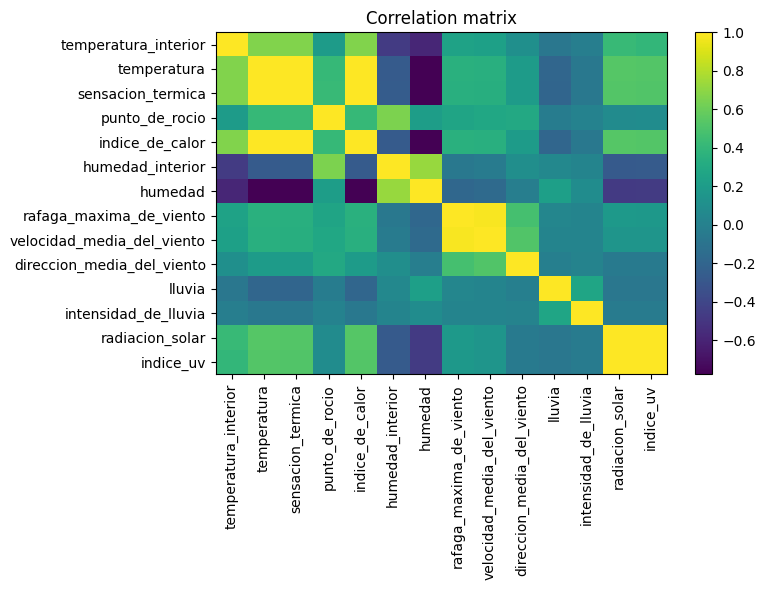

(['temperatura_interior',
  'temperatura',
  'sensacion_termica',
  'punto_de_rocio',
  'indice_de_calor',
  'humedad_interior',
  'humedad',
  'rafaga_maxima_de_viento',
  'velocidad_media_del_viento',
  'direccion_media_del_viento',
  'lluvia',
  'intensidad_de_lluvia',
  'radiacion_solar',
  'indice_uv'],
 (14, 14))

In [9]:
# ----------------------------
# 6) Correlation matrix (pairwise across variables)
# ----------------------------
good_vars_for_corr = [v for v in ds.data_vars if missing_df.set_index("variable").loc[v, "missing_pct"] < 50]

corr_df = ds[good_vars_for_corr].to_dataframe().corr()

print("Correlation matrix (vars with <50% missing)\n", corr_df)

plt.figure(figsize=(8, 6))
plt.imshow(corr_df.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

good_vars_for_corr, corr_df.shape



# ALL

Dataset: <xarray.Dataset> Size: 4MB
Dimensions:               (time: 25693)
Coordinates:
  * time                  (time) datetime64[ns] 206kB 2025-06-01 ... 2025-11-...
Data variables: (12/18)
    indoor_temperature    (time) float64 206kB ...
    temperature           (time) float64 206kB ...
    thermal_sensation     (time) float64 206kB ...
    indoor_dew_point      (time) float64 206kB ...
    dew_point             (time) float64 206kB ...
    indoor_heat_index     (time) float64 206kB ...
    ...                    ...
    atmospheric_pressure  (time) float64 206kB ...
    rainfall              (time) float64 206kB ...
    evapotranspiration    (time) float64 206kB ...
    rainfall_intensity    (time) float64 206kB ...
    solar_radiation       (time) float64 206kB ...
    uv_index              (time) float64 206kB ...

Variables: ['indoor_temperature', 'temperature', 'thermal_sensation', 'indoor_dew_point', 'dew_point', 'indoor_heat_index', 'heat_index', 'indoor_humidity', 'humi

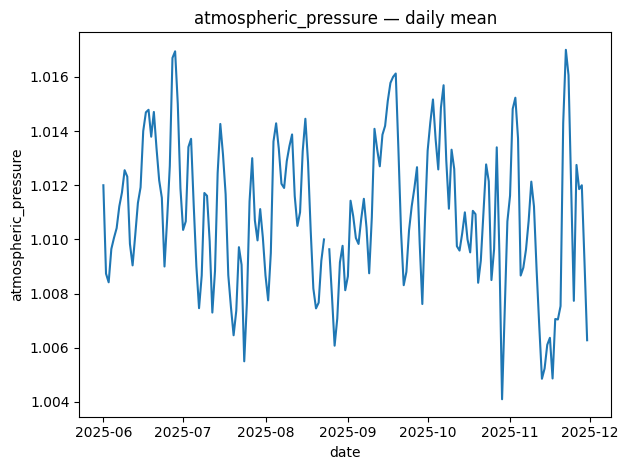

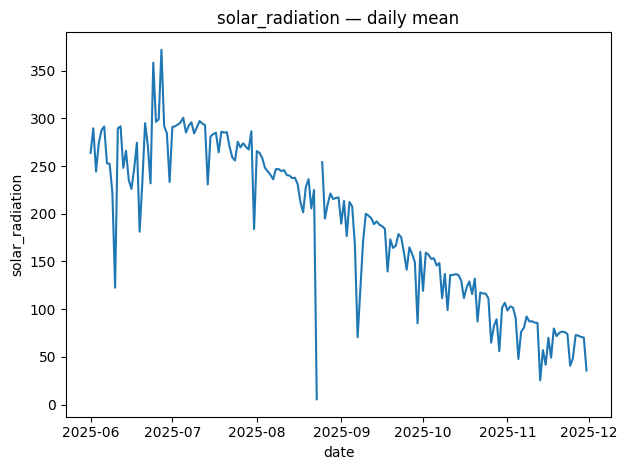

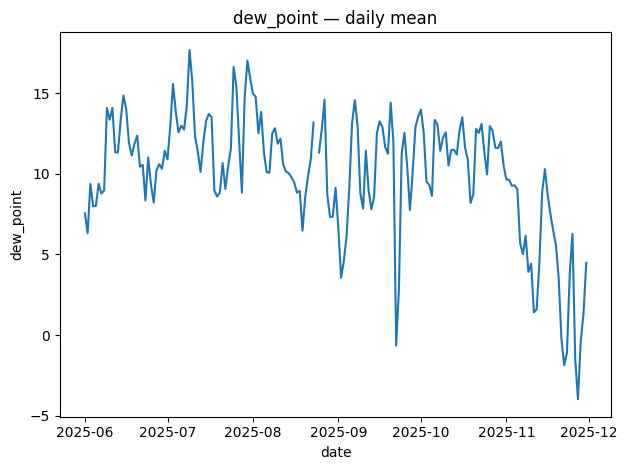

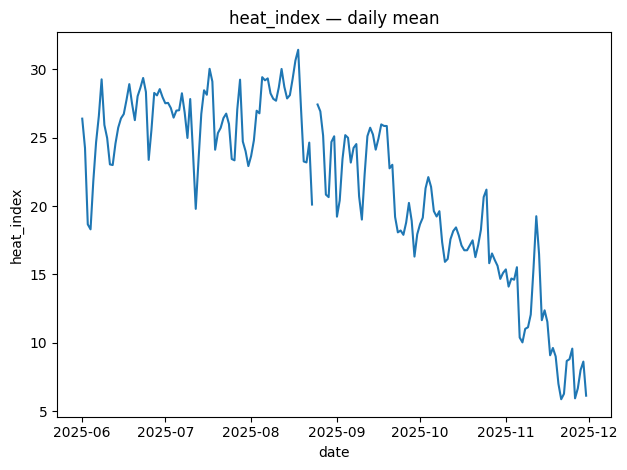

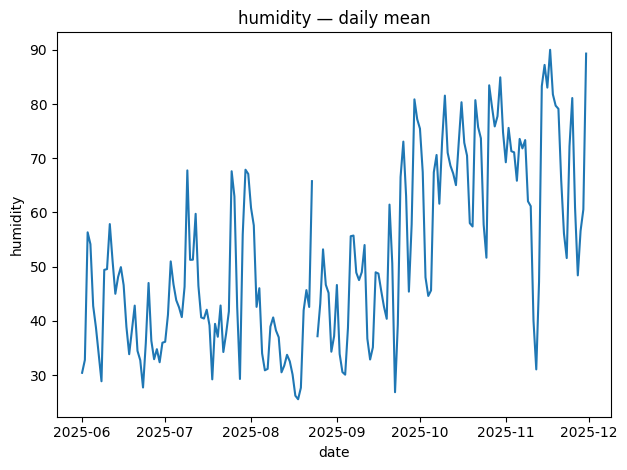

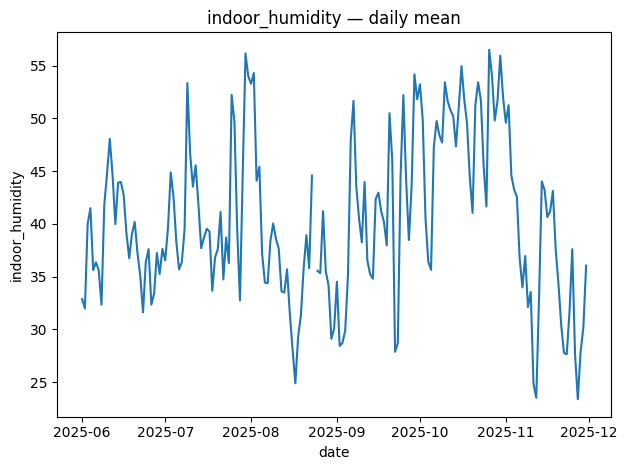

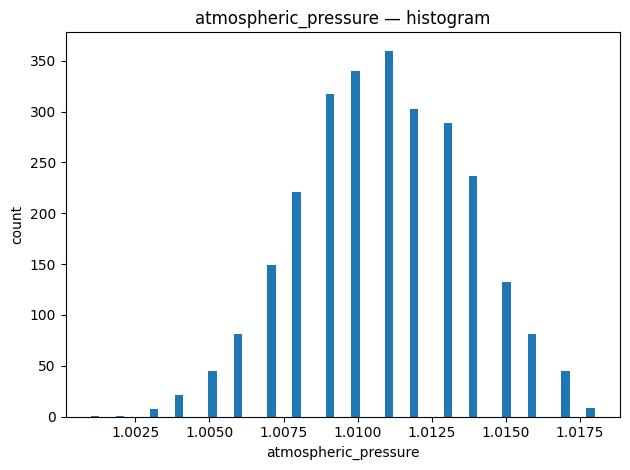

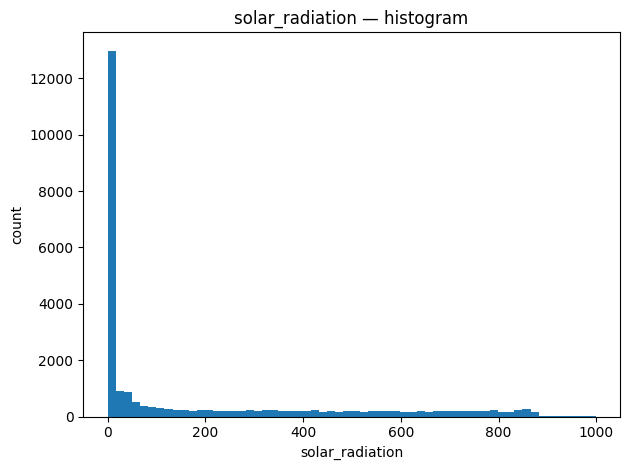

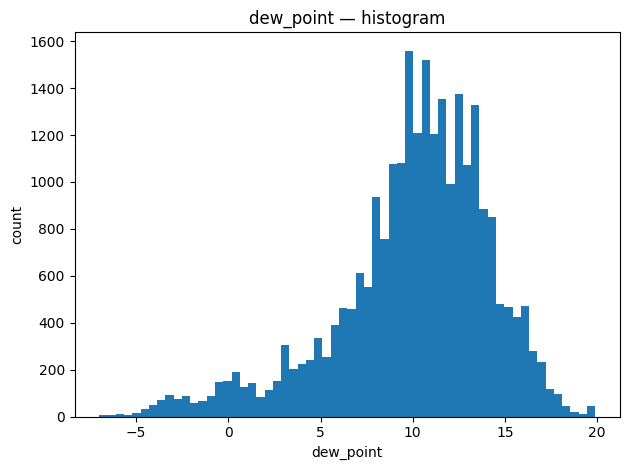

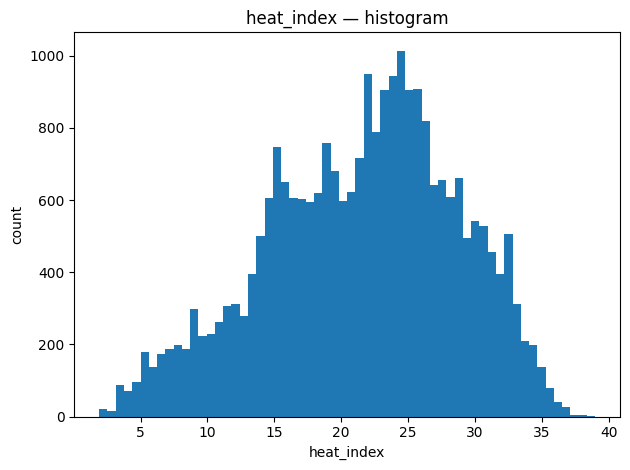

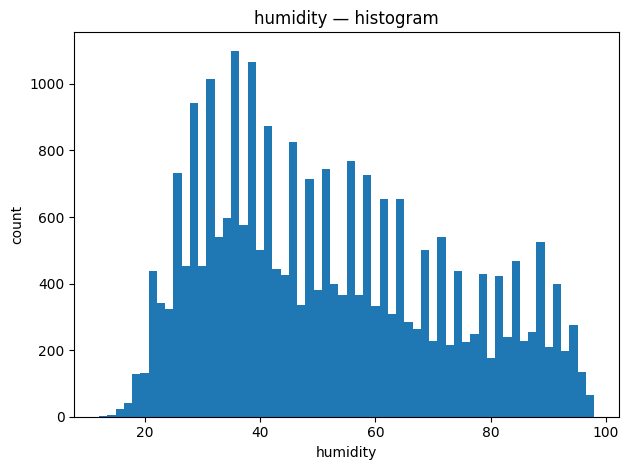

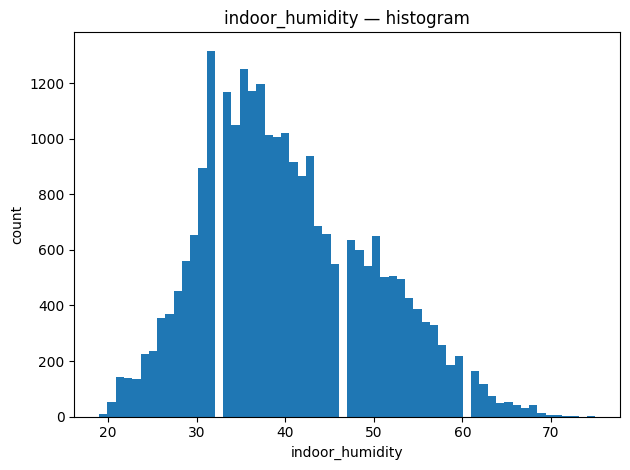


Correlation matrix (vars with <50% missing):
                     indoor_temperature  temperature  thermal_sensation  dew_point  heat_index  indoor_humidity  humidity  maximum_wind_gust  mean_wind_speed  mean_wind_direction  rainfall  rainfall_intensity  solar_radiation  uv_index
indoor_temperature                1.000        0.667              0.665      0.199       0.666           -0.464    -0.582              0.248            0.236                0.111    -0.069              -0.014            0.418     0.401
temperature                       0.667        1.000              0.999      0.417       1.000           -0.268    -0.776              0.353            0.344                0.198    -0.191              -0.061            0.530     0.523
thermal_sensation                 0.665        0.999              1.000      0.423       0.999           -0.260    -0.771              0.347            0.338                0.200    -0.196              -0.063            0.527     0.520
dew_point 

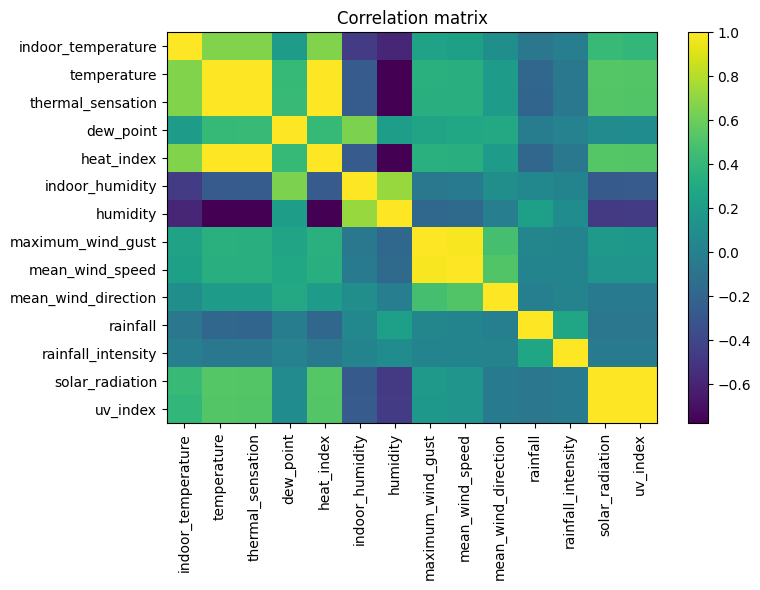

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/datassd/proyectos/terravision/terravision_sensor_data/canteras/canteras_atmos.nc"

# ----------------------------
# 1) Load + basic cleaning
# ----------------------------
ds = xr.open_dataset(PATH, engine="netcdf4")

# Drop NaT times, sort by time
time = pd.to_datetime(ds["time"].values)
valid = ~time.isna()
ds = ds.isel(time=valid).sortby("time")

# Drop duplicate timestamps (keep first)
t = pd.to_datetime(ds["time"].values)
dup_mask = t.duplicated(keep="first")
if dup_mask.any():
    ds = ds.isel(time=~xr.DataArray(dup_mask, dims="time"))

# Change variable names to english:
es_to_en = {
    "temperatura_interior": "indoor_temperature",
    "temperatura": "temperature",
    "sensacion_termica": "thermal_sensation",
    "punto_de_rocio_interior": "indoor_dew_point",
    "punto_de_rocio": "dew_point",
    "indice_de_calor_interior": "indoor_heat_index",
    "indice_de_calor": "heat_index",
    "humedad_interior": "indoor_humidity",
    "humedad": "humidity",
    "rafaga_maxima_de_viento": "maximum_wind_gust",
    "velocidad_media_del_viento": "mean_wind_speed",
    "direccion_media_del_viento": "mean_wind_direction",
    "presion_atmosferica": "atmospheric_pressure",
    "lluvia": "rainfall",
    "evapotranspiracion": "evapotranspiration",
    "intensidad_de_lluvia": "rainfall_intensity",
    "radiacion_solar": "solar_radiation",
    "indice_uv": "uv_index",
}

for k, v in es_to_en.items():
    ds = ds.rename({k: v})


print("Dataset:", ds)
print("\nVariables:", list(ds.data_vars))
print("\nTime range:", pd.to_datetime(ds.time.values[0]), "→", pd.to_datetime(ds.time.values[-1]))
print("N time steps:", ds.sizes["time"])

# ----------------------------
# 2) Cadence + gaps
# ----------------------------
t = pd.to_datetime(ds.time.values)
dt = t.to_series().diff().dropna()

print("\nCadence (timedelta) describe:")
print(dt.describe())

gap_threshold = pd.Timedelta(minutes=30)
gaps = dt[dt > gap_threshold].sort_values(ascending=False)

if len(gaps):
    gaps_df = pd.DataFrame({
        "gap": gaps.astype(str).values,
        "time_before_gap": (gaps.index - gaps.values).astype("datetime64[ns]"),
        "time_after_gap": gaps.index.astype("datetime64[ns]"),
    }).head(20)
    print(f"\nFound {len(gaps)} gaps > {gap_threshold}. Top 20:")
    print(gaps_df.to_string(index=False))
else:
    print(f"\nNo gaps > {gap_threshold} found.")

# ----------------------------
# 3) Missingness + stats per variable
# ----------------------------
missing_rows = []
stats_rows = []

for v in ds.data_vars:
    da = ds[v]
    if "time" not in da.dims or da.ndim != 1:
        continue

    arr = da.values.astype("float64")
    n = arr.size
    n_missing = int(np.isnan(arr).sum())
    missing_pct = (n_missing / n) * 100

    missing_rows.append({"variable": v, "missing_count": n_missing, "missing_pct": missing_pct})

    if n_missing == n:
        stats_rows.append({"variable": v, "dtype": str(da.dtype)})
        continue

    s = pd.Series(arr)
    stats_rows.append({
        "variable": v,
        "dtype": str(da.dtype),
        "min": float(np.nanmin(arr)),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "median": float(np.nanmedian(arr)),
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(np.nanmax(arr)),
    })

missing_df = pd.DataFrame(missing_rows).sort_values(["missing_pct", "variable"], ascending=[False, True])
stats_df = pd.DataFrame(stats_rows).sort_values("variable")

print("\nMissingness:")
print(missing_df.to_string(index=False))

print("\nStats:")
print(stats_df.to_string(index=False))

# ----------------------------
# 4) Time series plots (daily)
# ----------------------------
good_vars = missing_df.loc[missing_df["missing_pct"] < 100, "variable"].tolist()

preferred_order = [
    "temperatura", "humedad", "presion_atmosferica",
    "velocidad_media_del_viento", "rafaga_maxima_de_viento",
    "radiacion_solar", "lluvia", "intensidad_de_lluvia",
    "indice_uv", "sensacion_termica", "punto_de_rocio"
]
plot_vars = [v for v in preferred_order if v in good_vars][:6] or good_vars[:6]

df = ds[plot_vars].to_dataframe()

for v in plot_vars:
    series = df[v]
    plt.figure()
    if v in {"lluvia", "intensidad_de_lluvia"}:
        daily = series.resample("1D").sum(min_count=1)
        plt.plot(daily.index, daily.values)
        plt.title(f"{v} — daily sum")
    else:
        daily = series.resample("1D").mean()
        plt.plot(daily.index, daily.values)
        plt.title(f"{v} — daily mean")
    plt.xlabel("date")
    plt.ylabel(v)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 5) Histograms
# ----------------------------
for v in plot_vars:
    s = df[v].dropna()
    if len(s) == 0:
        continue
    plt.figure()
    plt.hist(s.values, bins=60)
    plt.title(f"{v} — histogram")
    plt.xlabel(v)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Correlation matrix (vars with <50% missing)
# ----------------------------
missing_map = missing_df.set_index("variable")["missing_pct"].to_dict()
corr_vars = [v for v in ds.data_vars if missing_map.get(v, 100) < 50]

corr = ds[corr_vars].to_dataframe().corr()
print("\nCorrelation matrix (vars with <50% missing):")
print(corr.round(3).to_string())

plt.figure(figsize=(8, 6))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()
